In [446]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [447]:
df = pd.read_csv("../data/marketing_campaign.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [448]:
print(f"The data has {df.shape[0]} rows and {df.shape[1]} columns")

The data has 2240 rows and 29 columns


In [449]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [450]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [451]:
df.duplicated().sum()

np.int64(0)

In [452]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [453]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## Exploratory Data Analysis

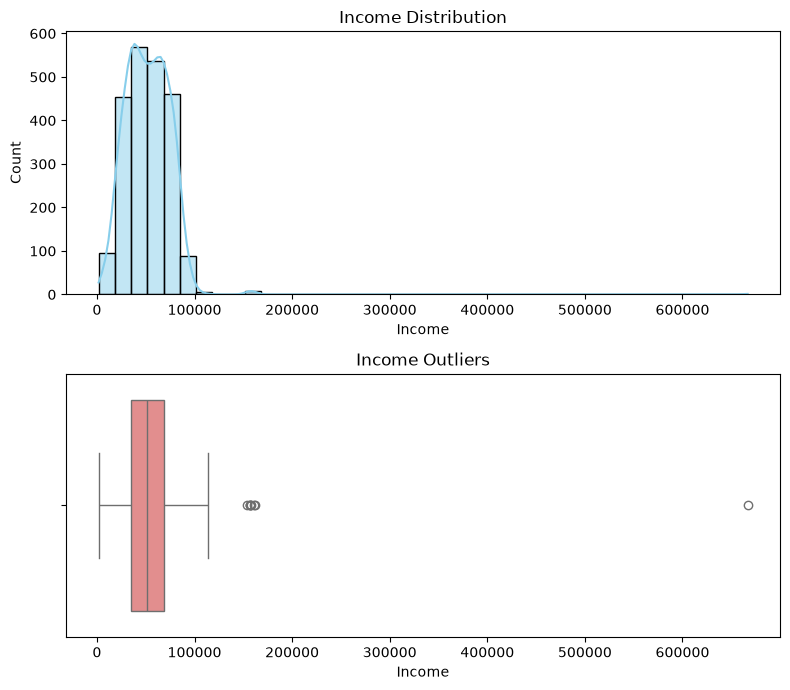

In [454]:
# What is the overall distribution of customer income, and are there extreme outliers that could distort clustering?
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7)) 

# Histogram to check distribution
sns.histplot(df['Income'], bins=40, kde=True, ax=ax1, color='skyblue') 
ax1.set_title('Income Distribution') 

# Boxplot to check outliers
sns.boxplot(x=df['Income'], ax=ax2, color='lightcoral') 
ax2.set_title('Income Outliers') 

plt.tight_layout() 
plt.savefig('../images/income_distribution_and_outlier.png', bbox_inches='tight')
plt.show()

**Insight**
* Income is mostly clustered around 50,000, but a massive outlier above 600,000 could heavily misinterpret clustering results.

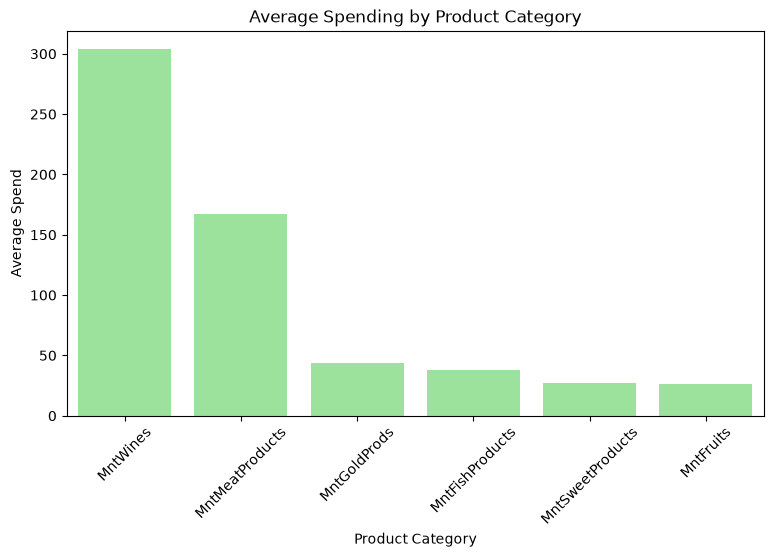

In [455]:
# How does spending behavior vary across product categories?
spending_columns = ['MntWines','MntFruits','MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds'] 
average_spend = df[spending_columns].mean().sort_values(ascending=False) 
plt.figure(figsize=(9,5)) 
sns.barplot(x=average_spend.index, y=average_spend.values, color='lightgreen') 
plt.xticks(rotation=45) 
plt.xlabel('Product Category')
plt.ylabel('Average Spend') 
plt.title('Average Spending by Product Category') 
plt.savefig('../images/average_spending_by_product_category.png', bbox_inches='tight')
plt.show()

**Insight**
* Customers spend the most on wines and meats, while spending very little on fruits and sweet products.

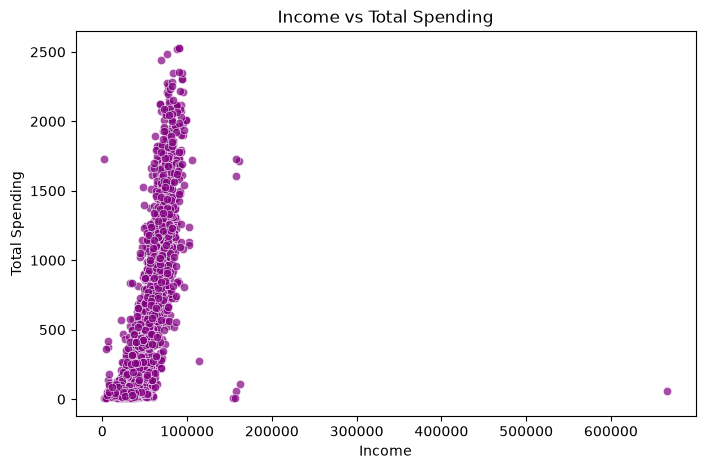

In [456]:
# Are customers with higher income actually spending more?
df['Total_Spending'] = df[spending_columns].sum(axis=1) 
plt.figure(figsize=(8,5)) 
sns.scatterplot(data=df, x='Income', y='Total_Spending', alpha=0.7, color='purple') 
plt.title('Income vs Total Spending') 
plt.xlabel('Income') 
plt.ylabel('Total Spending') 
plt.savefig('../images/income_vs_total_spending.png', bbox_inches='tight')
plt.show()

**Insight**
* Total spending strongly increases as income grows, while a few extreme high-income outliers spend very little.

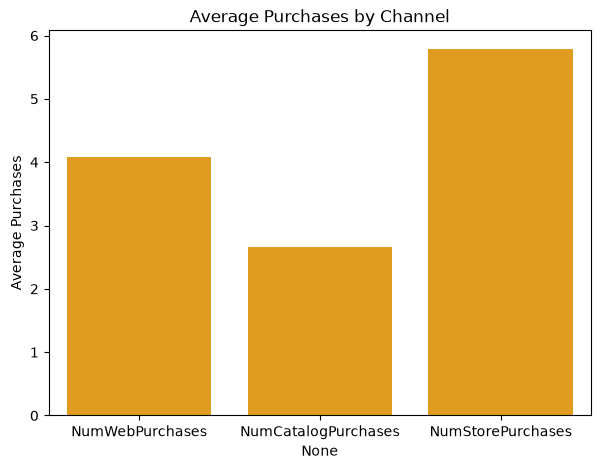

In [457]:
# Which purchase channel is most associated with total spending?
channel_columns = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases'] 
channel_mean = df[channel_columns].mean() 
plt.figure(figsize=(7,5)) 
sns.barplot(x=channel_mean.index, y=channel_mean.values, color='orange') 
plt.ylabel('Average Purchases') 
plt.title('Average Purchases by Channel') 
plt.savefig('../images/average_purchase_by_channel.png', bbox_inches='tight')
plt.show()

**Insight**
* In-store purchases are the most frequent channel, then web purchases, and catalog purchases being the lowest that is contributing to purchase.

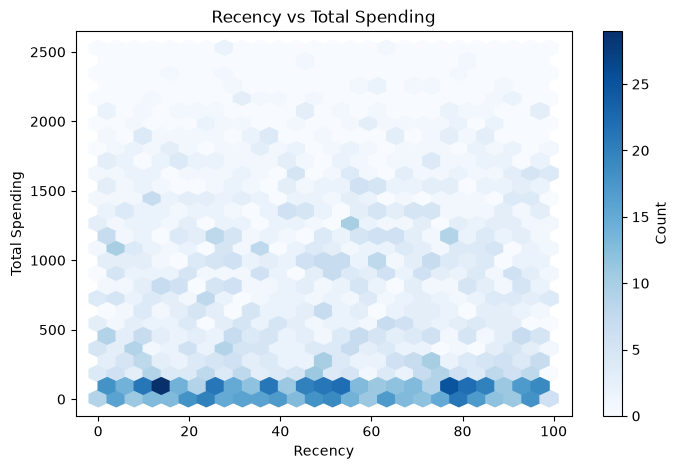

In [458]:
# Does recency relate to customer value and engagement?
plt.figure(figsize=(8,5)) 
plt.hexbin(df['Recency'], df['Total_Spending'], gridsize=25, cmap='Blues') 
plt.colorbar(label='Count') 
plt.xlabel('Recency') 
plt.ylabel('Total Spending') 
plt.title('Recency vs Total Spending') 
plt.savefig('../images/recency_vs_total_spending.png', bbox_inches='tight')
plt.show()

**Insight**
* Recency shows almost no clear relationship with total spending, because recent buyers do not certainly spend more money.

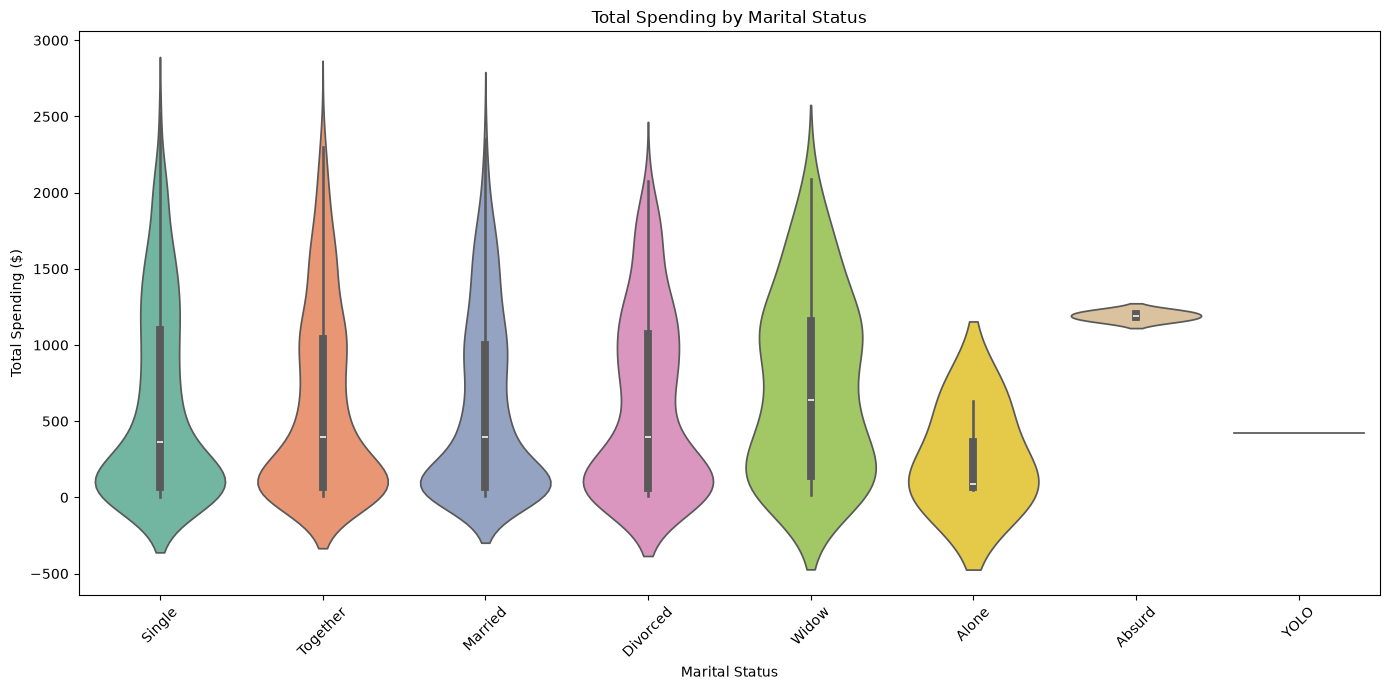

In [459]:
# How do marital status and household composition affect spending?
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=df, 
    x='Marital_Status', 
    y='Total_Spending', 
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title('Total Spending by Marital Status')
plt.ylabel('Total Spending ($)')
plt.xlabel('Marital Status')
plt.tight_layout()
plt.savefig('../images/total_spending_by_marital_status_eda.png', bbox_inches='tight')
plt.show()

**Insight**
* Widows show slightly higher spending, while single and married customers have heavily lower total spending.

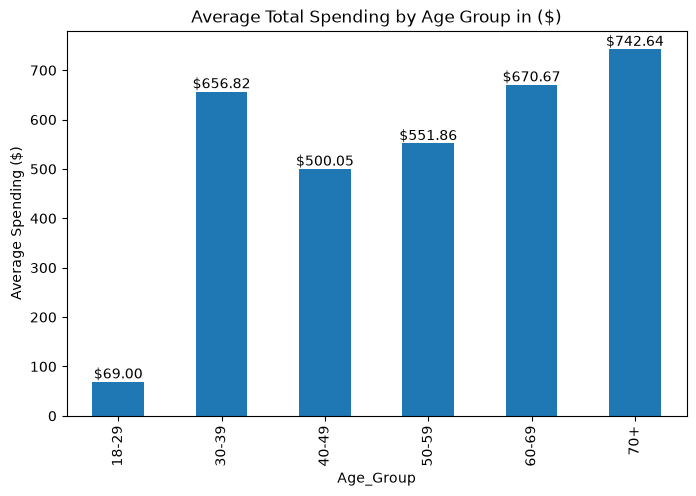

In [460]:
# Are there distinct age groups with different purchasing patterns?
# Calculate age
df['Age'] = 2026 - df['Year_Birth']

bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Group by age, calculate mean, and plot directly
ax = df.groupby('Age_Group')['Total_Spending'].mean().plot(kind='bar', figsize=(8, 5), title='Average Total Spending by Age Group in ($)', ylabel='Average Spending ($)')

ax.bar_label(ax.containers[0], fmt='$%.2f')
plt.savefig('../images/average_total_spending_by_age_group.png', bbox_inches='tight')

**Insight**
* Among all age group 70+ are spending the highest on average, then 60-69 and then 30-39. 

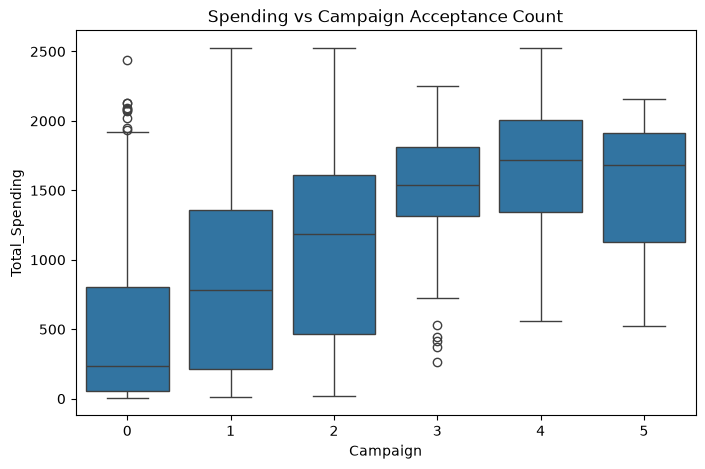

In [461]:
# Do customers who accepted previous campaigns spend more or buy differently?
total_accepted_campaign = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1) 
plt.figure(figsize=(8,5)) 
sns.boxplot(data=df, x=total_accepted_campaign, y='Total_Spending') 
plt.title('Spending vs Campaign Acceptance Count') 
plt.xlabel('Campaign')
plt.savefig('../images/spending_vs_campaign_acceptance.png', bbox_inches='tight')
plt.show()

**Insight**
* Customers who accepted more campaigns consistently show much higher total spending than those who accept none.

In [462]:
df.groupby(total_accepted_campaign)['Total_Spending'].median()

0     233.0
1     783.5
2    1184.5
3    1536.0
4    1720.0
5    1682.0
Name: Total_Spending, dtype: float64

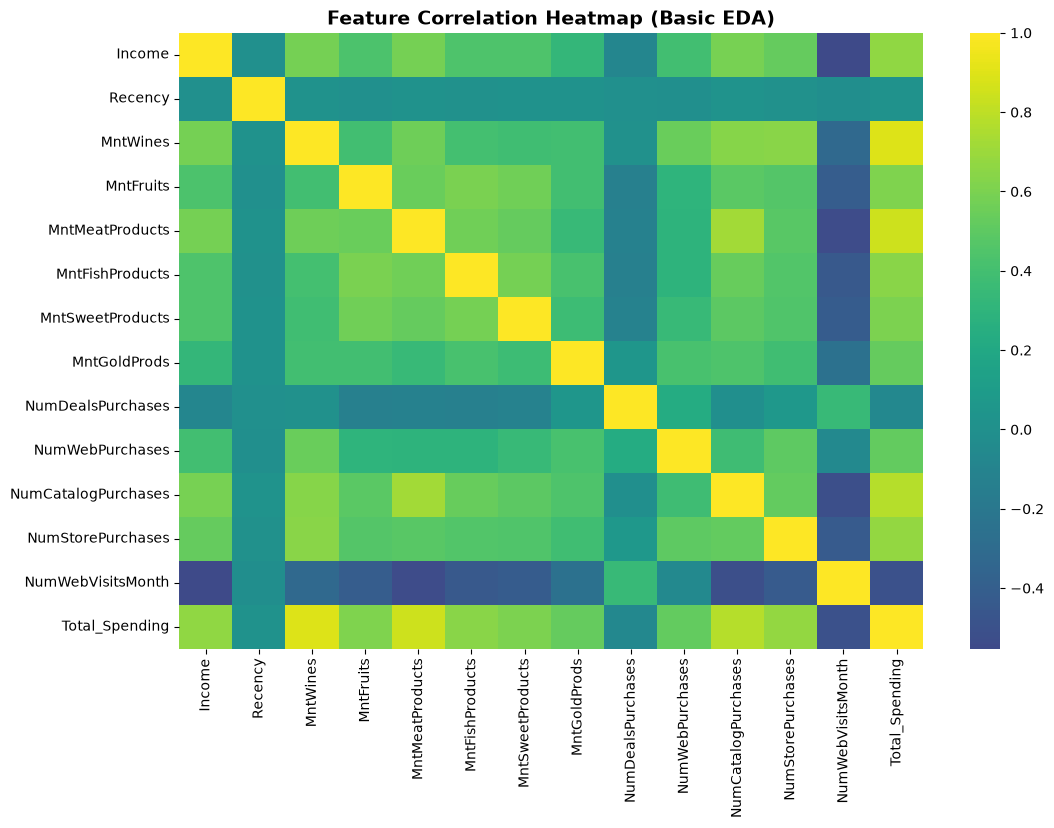

In [463]:
# What features are highly correlated, and which may be redundant for clustering?
numerical_columns = ['Income','Recency','MntWines','MntFruits','MntMeatProducts', 
            'MntFishProducts','MntSweetProducts','MntGoldProds', 'NumDealsPurchases',
            'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases',
            'NumWebVisitsMonth','Total_Spending'] 

plt.figure(figsize=(12,8)) 
corr = df[numerical_columns].corr() 
sns.heatmap(corr, cmap='viridis', center=0) 
plt.title('Feature Correlation Heatmap (Basic EDA)', fontsize=14, fontweight='bold') 
plt.savefig('../images/correalation_heatmap(EDA).png', bbox_inches='tight')
plt.show()

**Insight**
* People with higher incomes spend more money overall and buy more from catalogs and as customers tend to buy similar amounts across all product types, tracking every single category will be like repeating the same information.

## Data Cleaning

In [464]:
df.dtypes

ID                        int64
Year_Birth                int64
Education                   str
Marital_Status              str
Income                  float64
Kidhome                   int64
Teenhome                  int64
Dt_Customer                 str
Recency                   int64
MntWines                  int64
MntFruits                 int64
MntMeatProducts           int64
MntFishProducts           int64
MntSweetProducts          int64
MntGoldProds              int64
NumDealsPurchases         int64
NumWebPurchases           int64
NumCatalogPurchases       int64
NumStorePurchases         int64
NumWebVisitsMonth         int64
AcceptedCmp3              int64
AcceptedCmp4              int64
AcceptedCmp5              int64
AcceptedCmp1              int64
AcceptedCmp2              int64
Complain                  int64
Z_CostContact             int64
Z_Revenue                 int64
Response                  int64
Total_Spending            int64
Age                       int64
Age_Grou

In [465]:
# Filling missing values with median (Robust to outliers)
df["Income"] = df["Income"].fillna(df["Income"].median())

In [466]:
# Dropped ID column because it is identifier only, Z_CostContact and Z_Revenue because clustering algorithms learn from differences between customers but their std (variance) is zero
df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

In [467]:
# Filtered invalid ages to ensure data quality for clustering
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

In [468]:
# Calculated customer tenure in days to understand customer value
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y') 
reference_date = df['Dt_Customer'].max() 
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

In [469]:
df['Customer_Tenure_Days'].describe()

count    2237.000000
mean      353.790344
std       202.137961
min         0.000000
25%       181.000000
50%       356.000000
75%       529.000000
max       699.000000
Name: Customer_Tenure_Days, dtype: float64

In [470]:
# Dropped Dt_Customer column after calculating tenure because it is redundant now
df = df.drop(columns=['Dt_Customer'])

## Feature Engineering

In [471]:
# Calculated total number of children in the house
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [472]:
# Calculated web visit to purchase ratio to understand online engagement vs purchase behavior, avoiding division by zero
df['Web_Visit_to_Purchase_Ratio'] = ( df['NumWebVisitsMonth'] / (df['NumWebPurchases'].replace(0, 1)) )

In [473]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [474]:
# Replaced invalid values with nan because i found alone, absurd and yolo as typing errors and was not sure about category
df['Marital_Status'] = df['Marital_Status'].replace({ 
    'Married': 'Partnered', 
    'Together': 'Partnered', 
    'Single': 'Single', 
    'Divorced': 'Divorced',
    'Widow': 'Widow',
    'Alone': 'Unknown', 
    'Absurd': 'Unknown', 
    'YOLO': 'Unknown' 
    })

df['Marital_Status'].value_counts()

Marital_Status
Partnered    1443
Single        479
Divorced      231
Widow          77
Unknown         7
Name: count, dtype: int64

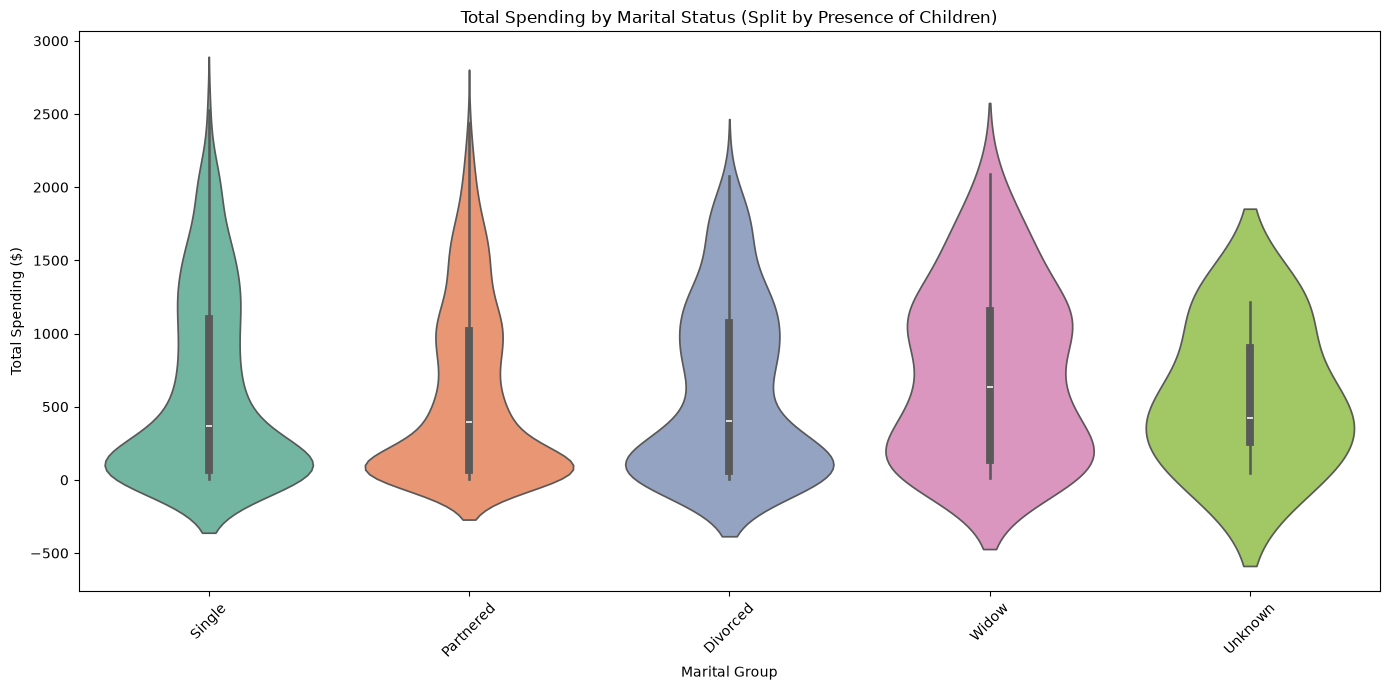

In [475]:
# How do marital groups affect spending?
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=df, 
    x='Marital_Status', 
    y='Total_Spending', 
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title('Total Spending by Marital Status (Split by Presence of Children)')
plt.ylabel('Total Spending ($)')
plt.xlabel('Marital Group')
plt.tight_layout()
plt.savefig('../images/total_spending_by_marital_status.png', bbox_inches='tight')
plt.show()

**Insight**
* Everyone mostly spends small amounts. widow spend the most on average. but, a few single and partnered people spend the highest amounts overall.

In [476]:
df.groupby('Marital_Status')['Total_Spending'].mean()

Marital_Status
Divorced     612.991342
Partnered    596.995842
Single       607.703549
Unknown      571.857143
Widow        738.818182
Name: Total_Spending, dtype: float64

In [477]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [478]:
# According to my research on google "Basic" and "2n Cycle" are below graduation levels.
df['Education'] = df['Education'].replace({ 
    'Basic': 'Below_Graduation', 
    '2n Cycle': 'Below_Graduation', 
    'Graduation': 'Graduation', 
    'Master': 'Postgraduate', 
    'PhD': 'Doctoral' 
    })

df["Education"].value_counts()

Education
Graduation          1127
Doctoral             485
Postgraduate         370
Below_Graduation     255
Name: count, dtype: int64

In [479]:
df.dtypes

Year_Birth                        int64
Education                           str
Marital_Status                      str
Income                          float64
Kidhome                           int64
Teenhome                          int64
Recency                           int64
MntWines                          int64
MntFruits                         int64
MntMeatProducts                   int64
MntFishProducts                   int64
MntSweetProducts                  int64
MntGoldProds                      int64
NumDealsPurchases                 int64
NumWebPurchases                   int64
NumCatalogPurchases               int64
NumStorePurchases                 int64
NumWebVisitsMonth                 int64
AcceptedCmp3                      int64
AcceptedCmp4                      int64
AcceptedCmp5                      int64
AcceptedCmp1                      int64
AcceptedCmp2                      int64
Complain                          int64
Response                          int64


In [480]:
# Dropped Redundant columns
redundant_columns = [ 
     'Age_Group', 'MntFruits',
    'MntFishProducts','MntSweetProducts',
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3', 'AcceptedCmp4',
    'AcceptedCmp5', 'Response', 'Complain', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Total_Spending'
    ]
for column in redundant_columns:
    df.drop(columns=column, inplace=True)

In [481]:
df.dtypes

Education                          str
Marital_Status                     str
Income                         float64
Recency                          int64
MntWines                         int64
MntMeatProducts                  int64
MntGoldProds                     int64
NumDealsPurchases                int64
NumWebPurchases                  int64
NumCatalogPurchases              int64
NumStorePurchases                int64
NumWebVisitsMonth                int64
Age                              int64
Customer_Tenure_Days             int64
Total_Children                   int64
Web_Visit_to_Purchase_Ratio    float64
dtype: object

In [482]:
df.describe()

,Income,Recency,MntWines,MntMeatProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Tenure_Days,Total_Children,Web_Visit_to_Purchase_Ratio
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,52227.407689,49.104604,303.995530,166.916853,43.968708,2.326777,4.087170,2.662494,5.794367,5.319177,57.098346,353.790344,0.950827,2.265866
std,25043.266830,28.956073,336.574382,225.661158,52.054318,1.932923,2.779461,2.923456,3.250940,2.426386,11.701917,202.137961,0.752037,2.350420
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000
25%,35523.000000,24.000000,24.000000,16.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,49.000000,181.000000,0.000000,0.666667
50%,51381.500000,49.000000,174.000000,67.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,56.000000,356.000000,1.000000,1.285714
75%,68281.000000,74.000000,504.000000,232.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,67.000000,529.000000,1.000000,3.000000
max,666666.000000,99.000000,1493.000000,1725.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,86.000000,699.000000,3.000000,20.000000


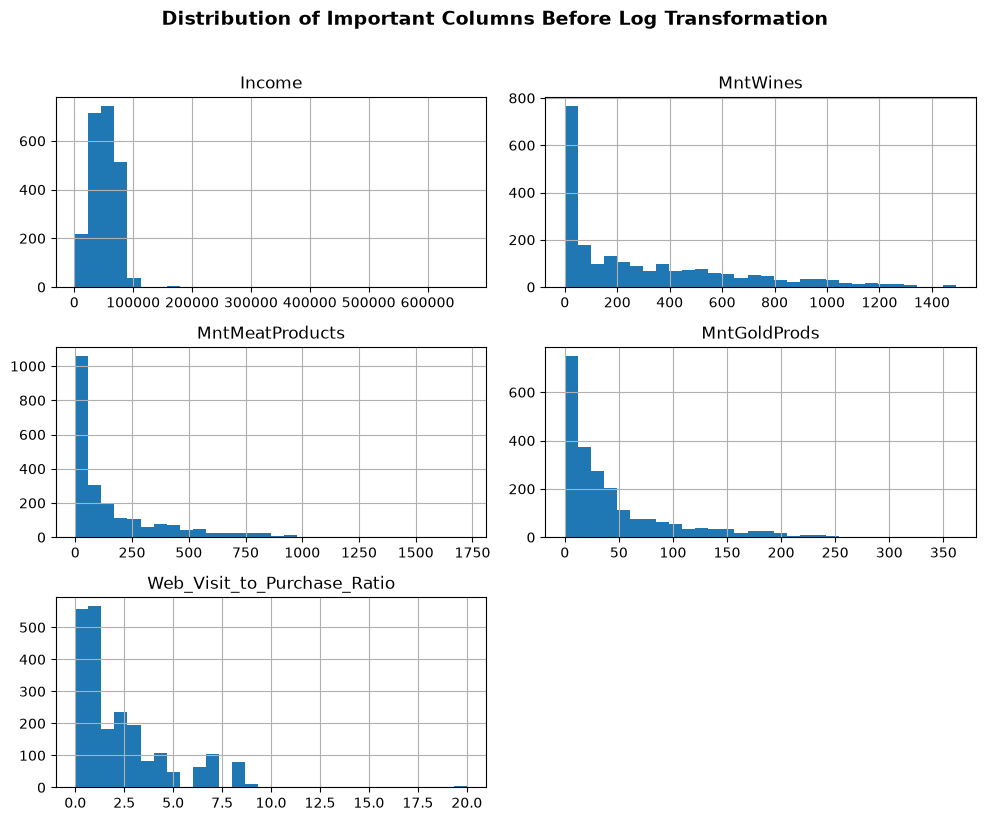

In [483]:
# Checking distribution of some important columns to check skewness before log transformation
important_columns = ['Income', 'MntWines', 'MntMeatProducts', 'MntGoldProds', 'Web_Visit_to_Purchase_Ratio'] 
df[important_columns].hist(figsize=(10, 8), bins=30) 
plt.suptitle('Distribution of Important Columns Before Log Transformation', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout() 
plt.savefig('../images/distribution_of_important_columns_before_log_transformation.png', bbox_inches='tight')
plt.show()

**Insight**
* Important columns like Income, MntWines, MntMeatProducts, MntGoldProds and Web_Visit_to_Purchase_Ratio have extreme outliers and data is right skewed. So, we will perform log transformation to reduce right skewness.

In [484]:
for column in important_columns: 
    df[column] = np.log1p(df[column])

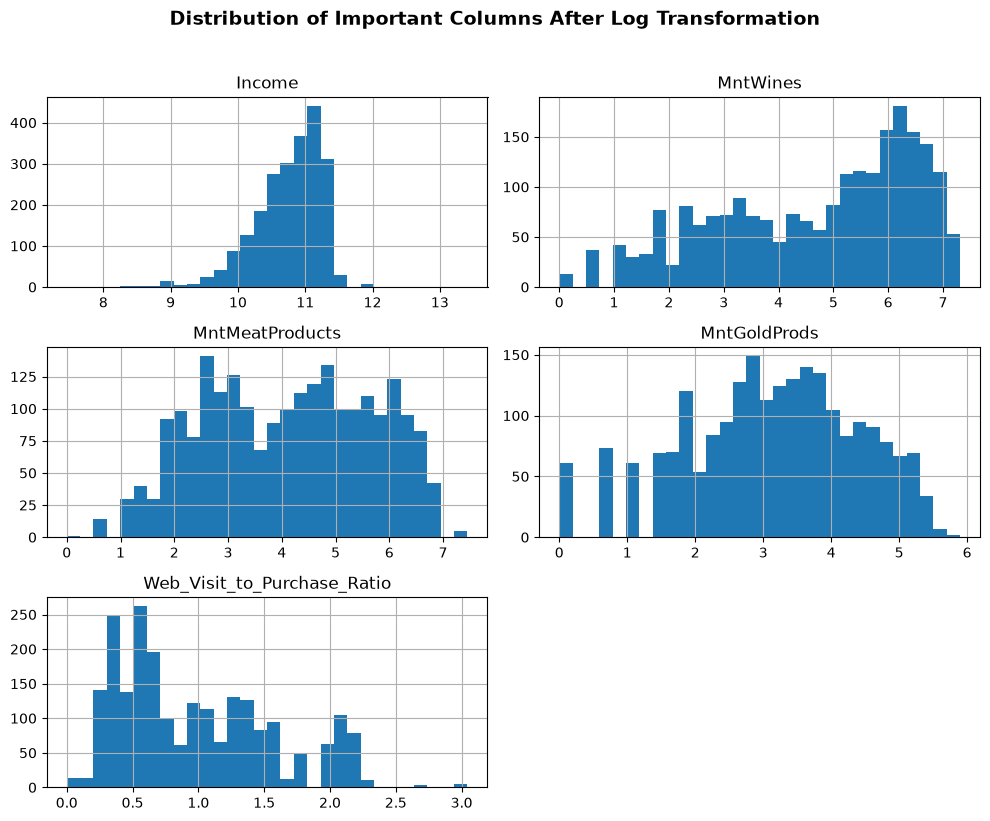

In [485]:
# Checking distribution of columns to check skewness after log transformation
df[important_columns].hist(figsize=(10, 8), bins=30) 
plt.suptitle('Distribution of Important Columns After Log Transformation', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout() 
plt.savefig('../images/distribution_of_important_columns_after_log_transformation.png', bbox_inches='tight')
plt.show()

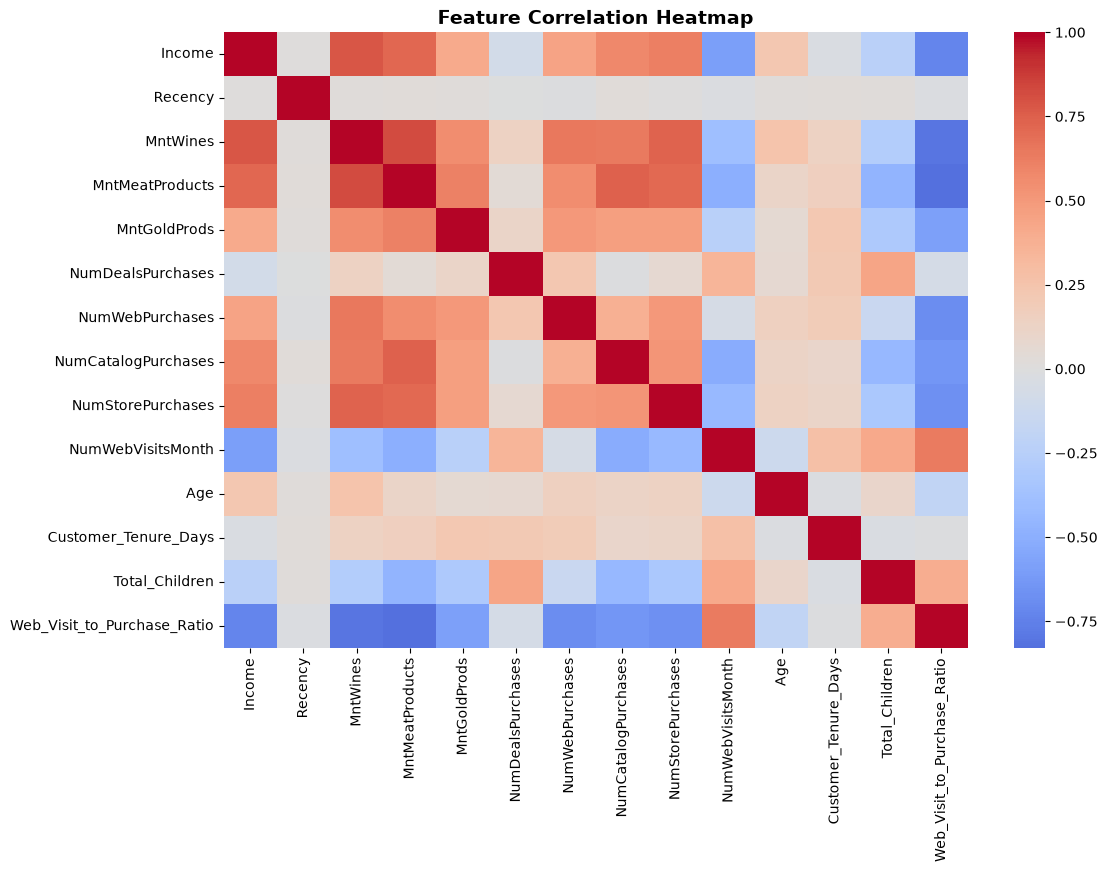

In [486]:
# Feature Correlation Heatmap
plt.figure(figsize=(12,8)) 
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0) 
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('../images/feature_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Insight**
* higher income strongly correlates with increased spending on wines and meat, as well as more catalog and store purchases. While, higher income negatively correlates with monthly web visits.

**Pipeline**

In [487]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines',
       'MntMeatProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Age', 'Customer_Tenure_Days', 'Total_Children',
       'Web_Visit_to_Purchase_Ratio'],
      dtype='str')

In [488]:
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_columns = [ 
    'Income', 'Recency', 'MntWines', 'MntMeatProducts', 'MntGoldProds', 
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Tenure_Days', 
    'Total_Children', 'Web_Visit_to_Purchase_Ratio' 
    ]

categorical_columns = ['Education', 'Marital_Status']

numeric_pipeline = Pipeline(steps=[ 
    ('scale', StandardScaler()) 
]) 

categorical_pipeline = Pipeline(steps=[ 
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
]) 

preprocessor = ColumnTransformer(transformers=[ 
    ('numerical', numeric_pipeline, numerical_columns), 
    ('categorical', categorical_pipeline, categorical_columns) 
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [489]:
X_processed = preprocessor.fit_transform(df)

In [490]:
X_processed

array([[ 0.4292774 ,  0.30727179,  0.98747406, ...,  1.        ,
         0.        ,  0.        ],
       [-0.02125088, -0.38358403, -1.21425543, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.84350205, -0.79809753,  0.76653286, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.3893336 ,  1.44718391,  1.18553004, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.77668445, -1.41986777,  0.76912422, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.24049896, -0.31449845, -0.12858613, ...,  0.        ,
         0.        ,  0.        ]], shape=(2237, 23))

**Elbow Method**

In [491]:
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

inertia = [] 
silhouette_scores = []

K = range(2, 11)

for k in K: 
    km = KMeans(n_clusters=k, random_state=42, n_init=20) 
    labels = km.fit_predict(X_processed) 
    inertia.append(km.inertia_) 
    silhouette_scores.append(silhouette_score(X_processed, labels))

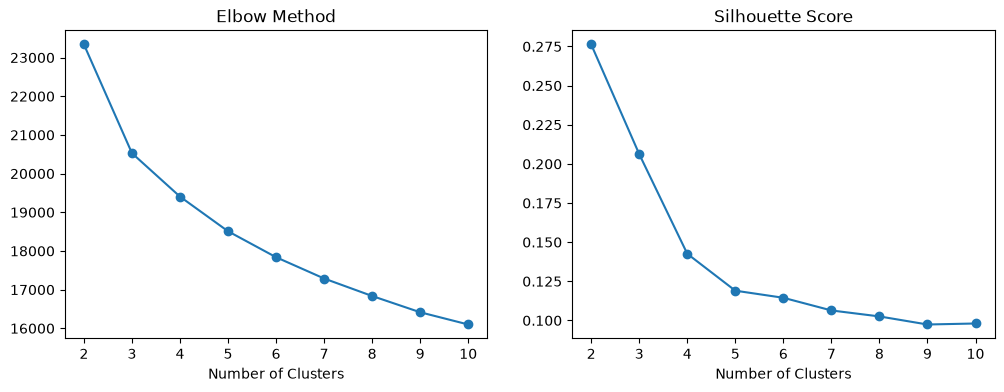

In [492]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 
ax[0].plot(K, inertia, marker='o') 
ax[0].set_title('Elbow Method') 
ax[0].set_xlabel('Number of Clusters') 
ax[1].plot(K, silhouette_scores, marker='o') 
ax[1].set_title('Silhouette Score') 
ax[1].set_xlabel('Number of Clusters')
plt.savefig('../images/elbow_and_silhouette_plots.png', bbox_inches='tight')

In [493]:
for k, score in zip(K, silhouette_scores): 
    print(f'k={k}: {score:.3f}')

k=2: 0.276
k=3: 0.206
k=4: 0.143
k=5: 0.119
k=6: 0.114
k=7: 0.106
k=8: 0.103
k=9: 0.097
k=10: 0.098


In [494]:
best_k = K[silhouette_scores.index(max(silhouette_scores))] 
print('Best k:', best_k)

Best k: 2


In [495]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10) 
df['Cluster'] = kmeans.fit_predict(X_processed) 
df['Cluster'].value_counts().sort_index()

Cluster
0    1265
1     972
Name: count, dtype: int64

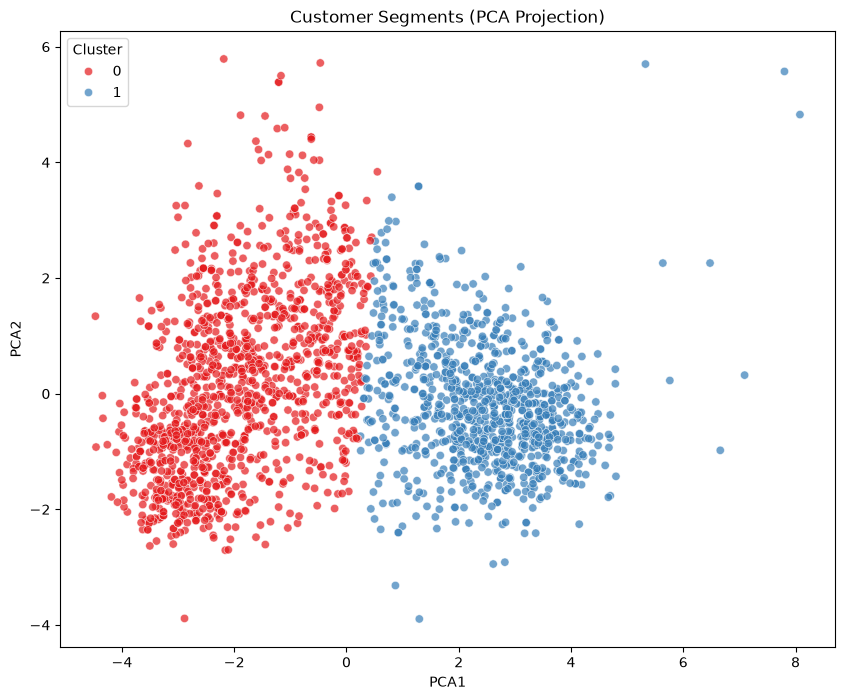

In [496]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Customer Segments (PCA Projection)')
plt.savefig('../images/pca_customer_segments_k2.png', bbox_inches='tight')
plt.show()

In [497]:
cluster_features = [ 
    'Income', 'Recency', 'MntWines', 'MntMeatProducts', 'MntGoldProds', 
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 
    'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Tenure_Days', 
    'Total_Children', 'Web_Visit_to_Purchase_Ratio' 
    ]

In [498]:
df.groupby('Cluster')[cluster_features].mean().round(2)

,Income,Recency,MntWines,MntMeatProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Tenure_Days,Total_Children,Web_Visit_to_Purchase_Ratio
Cluster,,,,,,,,,,,,,,
0,11.06,49.22,6.01,5.25,3.81,2.53,5.71,4.35,7.88,4.36,59.18,377.25,0.70,0.57
1,10.35,48.96,2.94,2.67,2.22,2.06,1.97,0.46,3.08,6.56,54.39,323.26,1.28,1.54


In [499]:
cluster_names = { 
    0: 'High Value Engaged Customer', 
    1: 'Low-Value Browsing Customer' 
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

In [500]:
df['Total_Purchases'] = ( df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] ) 
df['Total_Spending'] = ( df['MntWines'] + df['MntMeatProducts'] + df['MntGoldProds'] )

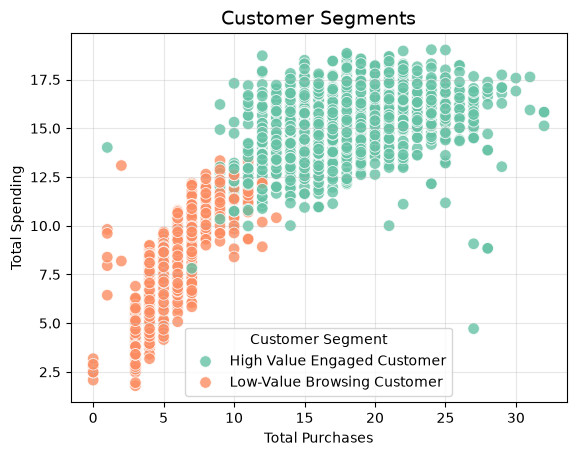

In [501]:
sns.scatterplot( data=df, x='Total_Purchases', y='Total_Spending', hue='Cluster_Name', palette='Set2', alpha=0.8, s=70 ) 
plt.title('Customer Segments', fontsize=14) 
plt.xlabel('Total Purchases') 
plt.ylabel('Total Spending') 
plt.legend(title='Customer Segment') 
plt.grid(alpha=0.3) 
plt.savefig('../images/customer_segments.png', bbox_inches='tight')
plt.show()

In [502]:
import joblib
joblib.dump(preprocessor, '../model/preprocessor.pkl') 
joblib.dump(kmeans, '../model/customer_segmentation_model.pkl')

['../model/customer_segmentation_model.pkl']